In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
ROOT_DIR = Path.home() / "EASM"
PROCESSED_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs" / "som_u850"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# =========================================================
# 0) input paths
# =========================================================
som_csv = OUTPUT_DIR / "som_daily_assignment.csv"
sst_file = PROCESSED_DIR / "oisst_regrid_jja_1982_2025.nc"
out_fig = OUTPUT_DIR / "sst_anom_node_composites_sig2.png"



In [4]:
# =========================================================
# 1) SOM 일별 할당표 읽기
# =========================================================
df = pd.read_csv(som_csv)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df[df["node"].between(1, 9)].copy()
df = df.sort_values("date").drop_duplicates(subset="date")


In [5]:
# =========================================================
# 2) OISST anomaly 읽기
# =========================================================
ds = xr.open_dataset(sst_file)
da = ds["sst"]

clim = da.groupby("time.dayofyear").mean("time")
sst = da.groupby("time.dayofyear") - clim


/home/user/miniforge3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# =========================================================
# 3) 좌표명 통일
# =========================================================
rename_dict = {}
if "latitude" in sst.dims:
    rename_dict["latitude"] = "lat"
if "longitude" in sst.dims:
    rename_dict["longitude"] = "lon"
if rename_dict:
    sst = sst.rename(rename_dict)

# zlev가 길이 1이면 미리 제거
if "zlev" in sst.dims and sst.sizes["zlev"] == 1:
    sst = sst.squeeze("zlev", drop=True)



In [7]:
# =========================================================
# 4) 시간축 정리
# =========================================================
sst_time = pd.to_datetime(sst["time"].values).normalize()
sst = sst.assign_coords(time=sst_time)



In [8]:
# =========================================================
# 5) 공통 날짜 추출
# =========================================================
common_time = np.intersect1d(sst["time"].values, df["date"].values)

print("len(sst time)   =", sst.sizes["time"])
print("len(df date)    =", len(df))
print("len(common_time)=", len(common_time))

if len(common_time) == 0:
    raise ValueError("공통 날짜가 없습니다.")



len(sst time)   = 4048
len(df date)    = 4048
len(common_time)= 4048


In [9]:
# =========================================================
# 6) 날짜 정합 + node 매핑
# =========================================================
sst_sel = sst.sel(time=common_time)

node_map = (
    df.set_index("date")["node"]
      .reindex(pd.to_datetime(common_time))
)

valid = ~node_map.isna().to_numpy()
sst_sel = sst_sel.isel(time=valid)
node_vals = node_map.to_numpy()[valid].astype(int)

print("len(sst_sel time) =", sst_sel.sizes["time"])
print("len(node_vals)    =", len(node_vals))

if sst_sel.sizes["time"] == 0:
    raise ValueError("sst_sel의 time 길이가 0입니다.")



len(sst_sel time) = 4048
len(node_vals)    = 4048


In [10]:
# =========================================================
# 7) node coordinate 부여
# =========================================================
sst_sel = sst_sel.assign_coords(node=("time", node_vals))



In [11]:
# =========================================================
# 8) node별 composite / std / n / se
# =========================================================
comp = sst_sel.groupby("node").mean("time")
std = sst_sel.groupby("node").std("time")
n = sst_sel.groupby("node").count("time")

nodes_all = np.arange(1, 10)
comp = comp.reindex(node=nodes_all)
std = std.reindex(node=nodes_all)
n = n.reindex(node=nodes_all)

se = std / np.sqrt(n)



In [12]:
# =========================================================
# 9) 2-sigma significance mask
#    |mean| >= 2 * SE
# =========================================================
sig2 = (np.abs(comp) >= 2.0 * se).fillna(False)



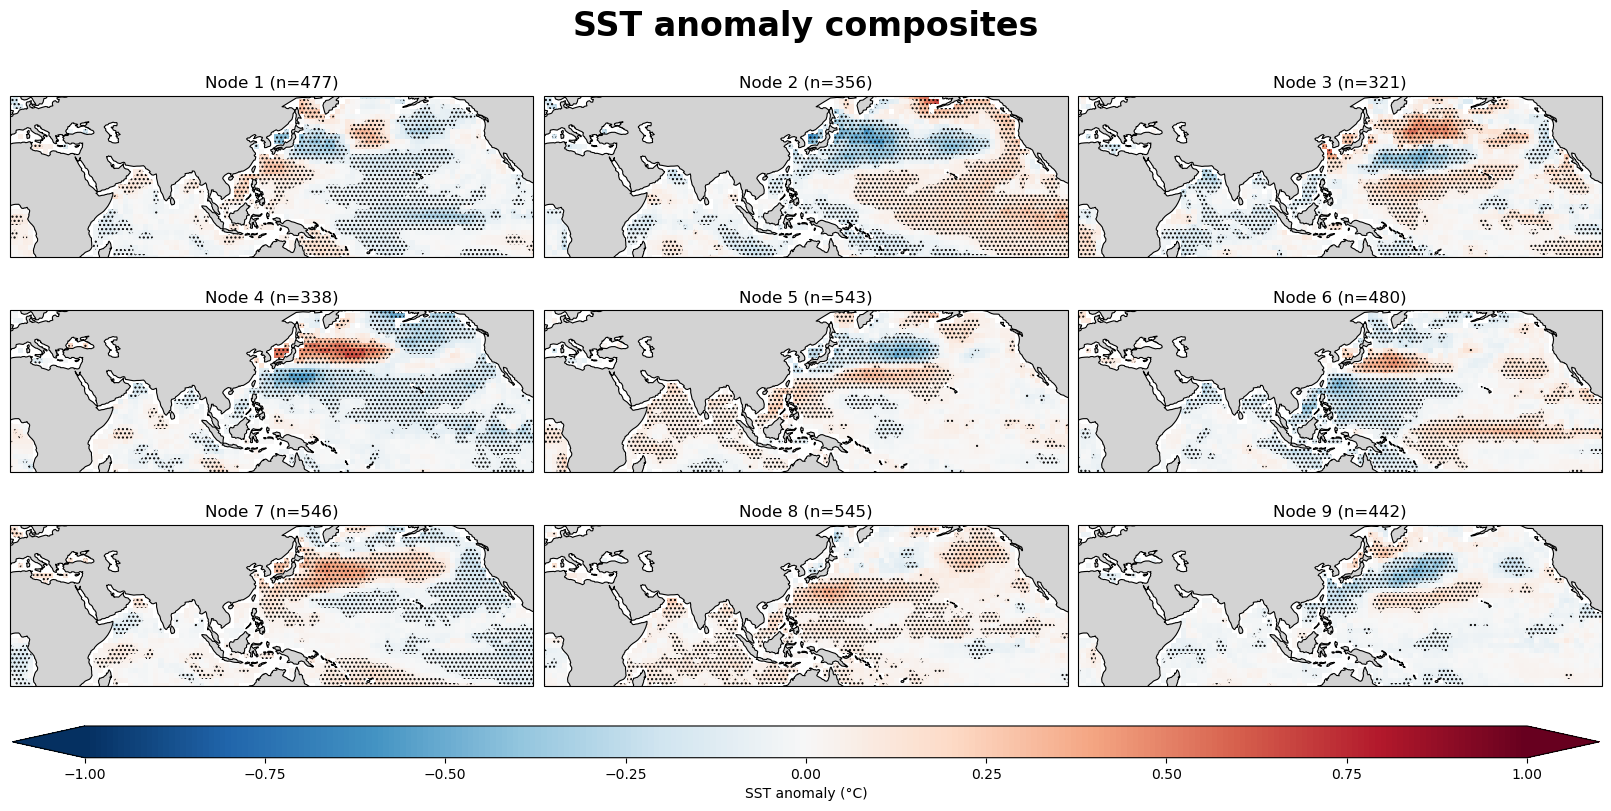

In [ ]:
# =========================================================
# 10) 그림
# =========================================================
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    3, 3, figsize=(16, 8), layout="constrained", subplot_kw={"projection": proj}
)

pcm = None

for i, ax in enumerate(axes.flat, start=1):
    ax.set_extent([0, 260, -20, 60], crs=ccrs.PlateCarree())

    da = comp.sel(node=i).squeeze(drop=True)
    mask = sig2.sel(node=i).squeeze(drop=True)

    if np.isfinite(da.values).any():
        pcm = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            vmin=-1.0,
            vmax=1.0,
            cmap="RdBu_r",
            extend="both",
        )

        ax.contourf(
            da["lon"].values,
            da["lat"].values,
            mask.astype(int).values,
            levels=[0.5, 1.5],
            hatches=["...."],
            colors="none",
            transform=ccrs.PlateCarree(),
        )

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.set_title(f"Node {i} (n={int(np.nanmax(n.sel(node=i).values))})")

if pcm is not None:
    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        extend="both",
        aspect=50,
    )
    cbar.set_label("SST anomaly (°C)")

fig.suptitle("SST anomaly composites", fontsize=24, fontweight="bold")

plt.savefig(out_fig, dpi=144, bbox_inches="tight")
plt.show()